# LUME-Cheetah virtual accelerator

This notebook builds a lume-cheetah model the long way — lattice, placeholder beam, simulator, action
variables — pokes it through the PV interface, then shows that
`example_virtual_accelerator.factory.build_accelerator` does the same four steps in
one call.

`gpsr.lume` and `lume_cheetah` hold no facility knowledge. Everything site-specific
lives in `example_virtual_accelerator/`:

| File | What it is |
|---|---|
| `lattice_6d.json` | the beamline geometry, as a Cheetah lattice |
| `variables.py` | the *action variables*: one per PV, carrying the local naming convention and the unit conversion between control-system engineering units and Cheetah's physics attributes |
| `factory.py` | assembles those two into a `LUMECheetahModel` |

`factory.py`'s builder is reached by a **dotted import-path string**, never imported
by `gpsr.lume`. That indirection is what lets a checkpoint record how to rebuild its
own accelerator without the library depending on any facility package.

In [1]:
import inspect

import matplotlib.pyplot as plt
import torch
from cheetah import Segment, ParticleBeam
from lume_cheetah import CheetahSimulator, LUMECheetahModel

# The facility-dependent half of the model: the action-variable classes, which
# carry the PV naming convention and the unit conversions. They live in a module
# rather than in a cell of this notebook so that they have an importable dotted
# path -- a serialized model records each variable as "<module>.<ClassName>", and
# a class defined in a notebook cell is "__main__.<ClassName>", which no other
# process can resolve. See the module docstring.
from example_virtual_accelerator import variables

In [2]:
# load cheetah segment from lattice json file
cheetah_segment = Segment.from_lattice_json(
    "example_virtual_accelerator/lattice_6d.json"
)

In [3]:
# inspect cheetah segment
cheetah_segment.elements

ModuleList(
  (0): Drift(name='d1', tracking_method='linear', length=tensor(0.1229))
  (1): TransverseDeflectingCavity(name='tdc', tracking_method='linear', length=tensor(0.6680), voltage=tensor(0.), phase=tensor(0.), frequency=tensor(2.8560e+09), misalignment=tensor([0., 0.]), tilt=tensor(1.5708), num_steps=1)
  (2): Drift(name='d2', tracking_method='linear', length=tensor(0.0522))
  (3): Quadrupole(name='q1', tracking_method='linear', length=tensor(0.1080), k1=tensor(12.1393), misalignment=tensor([0., 0.]), tilt=tensor(0.), num_steps=1)
  (4): Drift(name='d3', tracking_method='linear', length=tensor(0.2820))
  (5): Quadrupole(name='q2', tracking_method='linear', length=tensor(0.1080), k1=tensor(-10.9134), misalignment=tensor([0., 0.]), tilt=tensor(0.), num_steps=1)
  (6): Drift(name='d4', tracking_method='linear', length=tensor(2.6476))
  (7): Screen(name='s1', resolution=[200, 400], pixel_size=tensor([5.0000e-05, 5.0000e-05]), binning=1, misalignment=tensor([0., 0.]), method='cloud-

In [4]:
# create an initial particle beam distribution (just for testing, will be replaced during GPSR training)
design_energy = 125e6  # eV
test_beam = ParticleBeam.from_twiss(
    beta_x=torch.tensor(1e6),
    beta_y=torch.tensor(1e6),
    sigma_tau=torch.tensor(1e-3),
    num_particles=10000,
    energy=torch.tensor(design_energy),
)

In [5]:
# create CheetahSimulator
simulator = CheetahSimulator(
    segment=cheetah_segment, initial_beam_distribution=test_beam
)

In [6]:
# Build the LUME action variables: one object per control-system PV, each knowing
# which Cheetah element and attribute it reads/writes and the unit conversion
# between the two. Both halves of that -- the PV names and the conversions -- are
# facility dependent, which is why they are defined outside this notebook.
action_variables = variables.build_action_variables(cheetah_segment)

for action_variable in action_variables:
    unit = f" [{action_variable.unit}]" if action_variable.unit else ""
    print(
        f"{action_variable.name:20s} -> "
        f"{action_variable.element_name}.{action_variable.element_attribute}{unit}"
    )

Q1:BCTRL             -> q1.k1 [kG]
Q2:BCTRL             -> q2.k1 [kG]
Q3:BCTRL             -> q3.k1 [kG]
Q4:BCTRL             -> q4.k1 [kG]
TDC:AREQ             -> tdc.voltage [MV]
TDC:PREQ             -> tdc.phase [degrees]
S1:Image:ArrayData   -> s1.reading [counts]
S2:Image:ArrayData   -> s2.reading [counts]


In [7]:
# The definitions themselves. This is the code to rewrite for another facility:
# the control names, and the conversion between each PV's engineering units and
# the Cheetah attribute behind it.
print(inspect.getsource(variables))

"""Action variables for the example virtual accelerator.

A ``LUMECheetahModel`` is built from *action variables*: one object per control
-system PV, each knowing which Cheetah element and attribute it reads/writes and
the unit conversion between the two. That knowledge is **facility-dependent** --
it encodes the local PV naming convention and the engineering units the control
system speaks -- so it lives here rather than in any library. Everything these
classes inherit from (``lume_cheetah.actions``) is generic; only the names and
the conversion factors below are specific to this example.

Why a module and not a notebook cell
------------------------------------
These classes are defined in a file, and imported by the notebooks, so that they
have an **importable dotted path**. A serialized model records each variable as
``{"variable_class": "<module>.<ClassName>", ...fields}`` -- ``Variable`` is a
pydantic model, so its fields dump to JSON for free -- and rebuilding resolves
that path

In [8]:
# create LUMECheetahModel
lume_cheetah_model = LUMECheetahModel(
    simulator=simulator, action_variables=action_variables
)

In [9]:
# inspect the LUMECheetahModel
lume_cheetah_model

LUMECheetahModel(
  (simulator): CheetahSimulator(
    (segment): Segment(elements=ModuleList(
      (0): Drift(name='d1', tracking_method='linear', length=tensor(0.1229))
      (1): TransverseDeflectingCavity(name='tdc', tracking_method='linear', length=tensor(0.6680), voltage=tensor(0.), phase=tensor(0.), frequency=tensor(2.8560e+09), misalignment=tensor([0., 0.]), tilt=tensor(1.5708), num_steps=1)
       ⋮
      (14): Drift(name='d8', tracking_method='linear', length=tensor(0.3997))
      (15): Screen(name='s2', resolution=[200, 400], pixel_size=tensor([5.0000e-05, 5.0000e-05]), binning=1, misalignment=tensor([0., 0.]), method='cloud-in-cell', kde_bandwidth=tensor(5.0000e-05), is_active=True)
    ), name='lattice_6d')
    (_initial_segment): Segment(elements=ModuleList(
      (0): Drift(name='d1', tracking_method='linear', length=tensor(0.1229))
      (1): TransverseDeflectingCavity(name='tdc', tracking_method='linear', length=tensor(0.6680), voltage=tensor(0.), phase=tensor(0.), fr

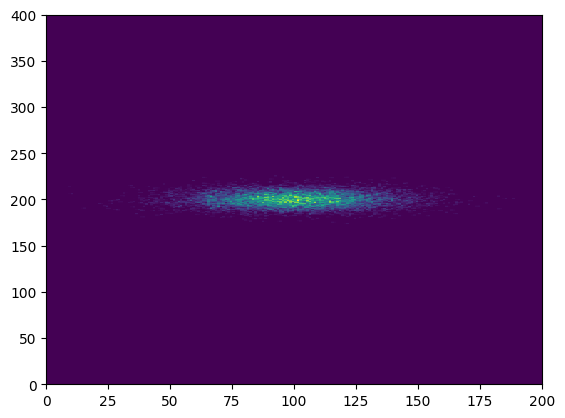

In [10]:
# turn TCAV off and see screen 1:
lume_cheetah_model.set({"TDC:AREQ": torch.tensor(0.0)})
s1 = lume_cheetah_model.get("S1:Image:ArrayData")
plt.pcolormesh(s1.T)

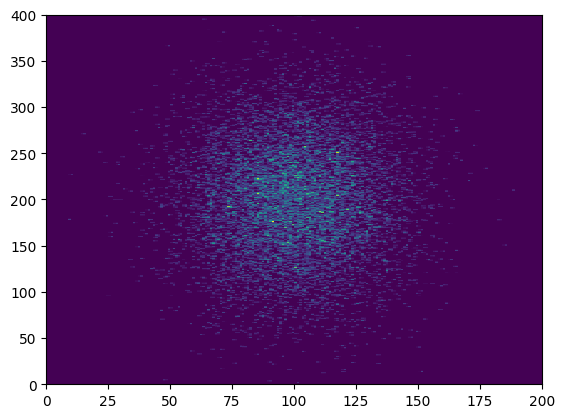

In [11]:
# turn TCAV on and see screen 1:
lume_cheetah_model.set({"TDC:AREQ": torch.tensor(3.0)})
s1 = lume_cheetah_model.get("S1:Image:ArrayData")
plt.pcolormesh(s1.T)

In [12]:
lume_cheetah_model.simulator.segment.tdc

TransverseDeflectingCavity(name='tdc', tracking_method='linear', length=tensor(0.6680), voltage=tensor(3000000.), phase=tensor(0.), frequency=tensor(2.8560e+09), misalignment=tensor([0., 0.]), tilt=tensor(1.5708), num_steps=1)

In [13]:
# Everything above -- load the lattice, make a placeholder beam, wrap it in a
# CheetahSimulator, attach the action variables -- is what the example's accelerator
# builder does in one call. `gpsr.lume` reaches that builder by *dotted path* and
# never imports it, so the string below is the facility seam: it is what a model
# spec carries, and what a trained checkpoint records in order to rebuild the
# accelerator it was fit through.
from example_virtual_accelerator.factory import build_accelerator, BUILDER_IMPORT_PATH

BUILDER_IMPORT_PATH

'example_virtual_accelerator.factory.build_accelerator'

In [14]:
# Same model, one call. Compare the PV *interface* rather than the readings: the
# hand-built model above tracks the 10k-particle test beam and has had TDC:AREQ
# changed, while the builder makes a single-particle placeholder at the reference
# energy -- a reconstruction replaces the beam on every forward pass anyway.
rebuilt = build_accelerator(
    lattice="example_virtual_accelerator/lattice_6d.json",
    energy=design_energy,
)

assert set(rebuilt.supported_variables) == set(lume_cheetah_model.supported_variables)
for pv_name, action_variable in rebuilt.supported_variables.items():
    assert type(action_variable) is type(
        lume_cheetah_model.supported_variables[pv_name]
    )

print(f"builder reproduces all {len(rebuilt.supported_variables)} PVs")

builder reproduces all 8 PVs
